In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import python libraries and kind framework --!

import torch
import numpy as np

from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler

import utils_data
import utils_plot

In [2]:
data_nsample = 144
datadir      = '../../data/baselines/m4_test'
data         = utils_data.read_datafile(f'{datadir}/eval', data_nsample)

print(data.shape)

torch.Size([414, 144, 1])


In [3]:
# --! load a trained KIND model --!

model = torch.load('../../models/baselines/m4_h_kind.pt', weights_only=False)
model.eval()

model(
  (operator_stat): operator_stationary(
    (fun_enc): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=48, out_features=128, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=128, out_features=1152, bias=True)
          (1): Identity()
        )
      )
    )
    (mod_mean): Linear(in_features=12, out_features=12, bias=False)
    (mod_var_gen): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=24, out_features=128, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=128, out_features=432, bias=True)
          (1): Identity()
        )
      )
    )
    

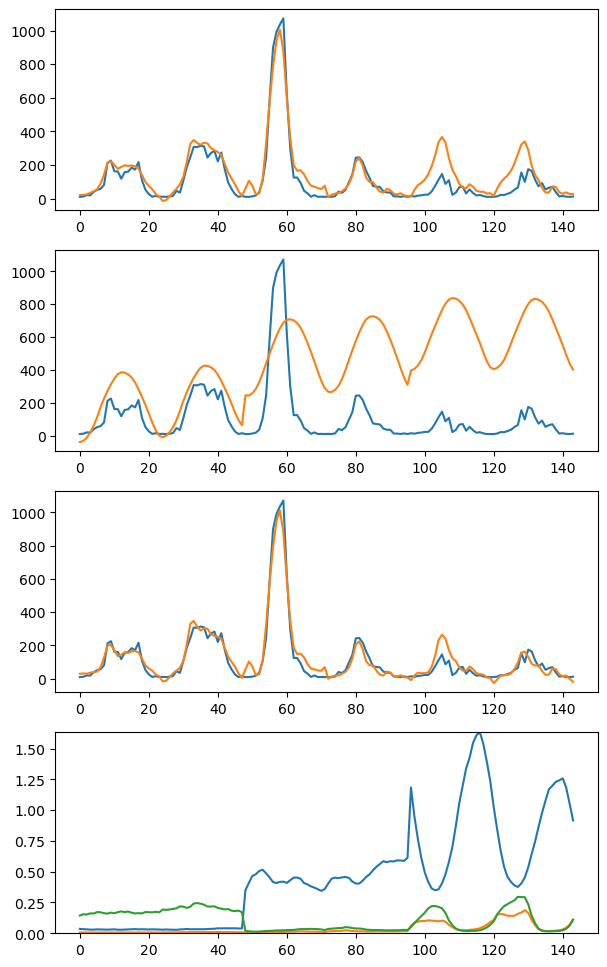

In [9]:
lookback_nsample   = model.lookback_nsample
forecast_nsample   = model.forecast_nsample

jdata = 133 # 44, 88, 123, 222, 256, 100, 99, 192, 413, 12, 333, 133, 348

with torch.no_grad():
    model_i  = data[[jdata], :lookback_nsample, :]
    model_o  = model(model_i)

    blend      = model_o[0]
    stat       = model_o[1]
    stat_zeta  = torch.exp(model_o[2]) + 1e-6
    trans      = model_o[3]
    trans_zeta = torch.exp(model_o[4]) + 1e-6
    alpha      = model_o[9]

    # --! display results --!

    w  = 7
    h  = 3
    nu = 4

    plt.figure(figsize=(w, nu*h))

    plt.subplot(nu, 1, 1)
    plt.plot(data[jdata, :, 0])
    plt.plot(blend[0, :, 0])

    plt.subplot(nu, 1, 2)
    plt.plot(data[jdata, :, 0])
    plt.plot(stat[0, :, 0])

    plt.subplot(nu, 1, 3)
    plt.plot(data[jdata, :, 0])
    plt.plot(trans[0, :, 0])

    stat_zeta_max  = torch.max(stat_zeta)
    trans_zeta_max = torch.max(trans_zeta)
    zeta_max       = stat_zeta_max if stat_zeta_max > trans_zeta_max else trans_zeta_max
    lim_max        = zeta_max if zeta_max > 1.0 else 1.0
    plt.subplot(nu, 1, 4)
    plt.plot(stat_zeta[0, :, 0])
    plt.plot(trans_zeta[0, :, 0])
    plt.plot(alpha[0, :, 0])
    plt.ylim((0, lim_max))

    plt.show()

    datasaved = True

    if datasaved:
        savedir  = '../../savedata/baselines/m4'

        truth    = data[jdata]
        step     = torch.arange(len(truth)).reshape(-1, 1)
        savedata = np.expand_dims(np.concatenate([step, truth], axis=1), 0)
        utils_data.write_datafile(f'{savedir}/m4_h_{jdata}_truth', savedata, delim=' ')

        savedata = np.expand_dims(np.concatenate([
            step[lookback_nsample:],
            stat[0, lookback_nsample:], trans[0, lookback_nsample:], blend[0, lookback_nsample:],
            stat_zeta[0, lookback_nsample:], trans_zeta[0, lookback_nsample:],
            alpha[0, lookback_nsample:]], axis=1), 0)
        utils_data.write_datafile(f'{savedir}/m4_h_{jdata}_forecast', savedata, delim=' ')

In [5]:
def smape(y_true, y_pred):
    res = []

    for j in range(len(y_true)):
        denominator = (np.abs(y_true[j]) + np.abs(y_pred[j])) / 2.0
        diff = np.abs(y_true[j] - y_pred[j])
        smape_values = diff / denominator

        res.append(100. * np.mean(smape_values))

    return res

def smape2(A, F):
    tmp = 2 * np.abs(F - A) / (np.abs(A) + np.abs(F))
    len_ = np.count_nonzero(~np.isnan(tmp))
    if len_ == 0 and np.nansum(tmp) == 0: # Deals with a special case
        return 100
    return 100 / len_ * np.nansum(tmp)

def MSE(pred, true):
    return np.mean((pred - true) ** 2)

def MAE(pred, true):
    return np.mean(np.abs(pred - true))

In [7]:
lookback_nsample   = model.lookback_nsample
forecast_nsample   = model.forecast_nsample

true  = []
blend = []
stat  = []
trans = []
alpha = []

ndata = len(data)
print(f'inf > there are {ndata} time series')

with torch.no_grad():
    for j in range(ndata):
        model_i  = data[[j], :lookback_nsample, :]
        model_o  = model(model_i)

        truth      = data[[j], lookback_nsample:, :]
        this_blend = model_o[0][:, lookback_nsample:]
        this_stat  = model_o[1][:, lookback_nsample:]
        this_trans = model_o[3][:, lookback_nsample:]
        this_alpha = model_o[9][:, lookback_nsample:]

        true.append(truth)
        blend.append(this_blend)
        stat.append(this_stat)
        trans.append(this_trans)
        alpha.append(this_alpha)

alpha = np.mean(alpha)
print(f'inf > mean alpha is {alpha:.2f}')

true  = np.array(true)
true  = true.reshape(-1, true.shape[-2], true.shape[-1])

blend = np.array(blend)
blend = blend.reshape(-1, blend.shape[-2], blend.shape[-1])

stat  = np.array(stat)
stat  = stat.reshape(-1, stat.shape[-2], stat.shape[-1])

trans = np.array(trans)
trans = trans.reshape(-1, trans.shape[-2], trans.shape[-1])

blend_mae = []
for t, p in zip(true, blend):
    scaler = MinMaxScaler()
    tmp    = np.concatenate([t, p], axis=1)
    tmp    = scaler.fit_transform(tmp)
    err    = MAE(tmp[:, 0], tmp[:, 1])
    blend_mae.append(err)

stat_mae = []
for t, p in zip(true, stat):
    scaler = MinMaxScaler()
    tmp    = np.concatenate([t, p], axis=1)
    tmp    = scaler.fit_transform(tmp)
    err    = MAE(tmp[:, 0], tmp[:, 1])
    stat_mae.append(err)

trans_mae = []
for t, p in zip(true, trans):
    scaler = MinMaxScaler()
    tmp    = np.concatenate([t, p], axis=1)
    tmp    = scaler.fit_transform(tmp)
    err    = MAE(tmp[:, 0], tmp[:, 1])
    trans_mae.append(err)

blend_mae = np.mean(blend_mae)
stat_mae  = np.mean(stat_mae)
trans_mae = np.mean(trans_mae)
print(f'blend mae is {blend_mae:.3f}')
print(f'stat mae is {stat_mae:.3f}')
print(f'trans mae is {trans_mae:.3f}')

stat_smape_arr  = smape(true, stat)
trans_smape_arr = smape(true, trans)
blend_smape_arr = smape(true, blend)

print(np.argmax(stat_smape_arr))
print(np.argmax(trans_smape_arr))
print(np.argmax(blend_smape_arr))

print(np.argmin(stat_smape_arr))
print(np.argmin(trans_smape_arr))
print(np.argmin(blend_smape_arr))

stat_smape  = smape2(true, stat)
trans_smape = smape2(true, trans)
blend_smape = smape2(true, blend)

print(f'inf > sMAPE for stat is {stat_smape:.4f}')
print(f'inf > sMAPE for trans is {trans_smape:.4f}')
print(f'inf > sMAPE for blend is {blend_smape:.4f}')

inf > there are 414 time series
inf > mean alpha is 0.37
blend mae is 0.080
stat mae is 0.120
trans mae is 0.077
133
348
348
181
186
186
inf > sMAPE for stat is 26.9400
inf > sMAPE for trans is 13.9938
inf > sMAPE for blend is 14.7750
